In [ ]:
import importlib
import functions2 as fct
importlib.reload(fct)

<module 'functions2' from '/Users/kylemcgillivray/Python/Dissertation/Masters-Dissertation/functions2.py'>

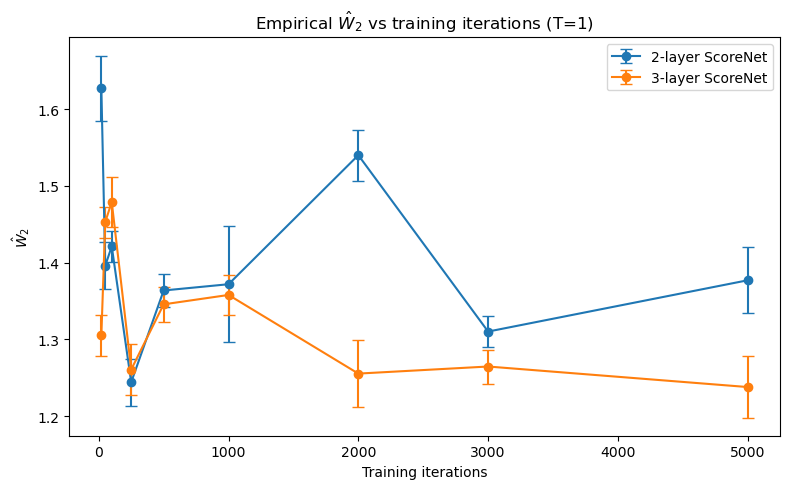

In [12]:
results_T1 = fct.load_results("outputs/results_T1.pt")
fct.plot_W2_curve(results_T1, title_suffix="(T=1)")

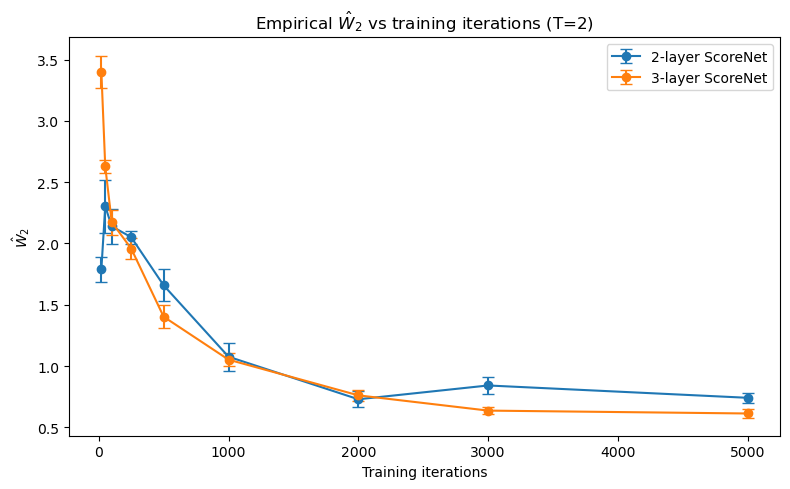

In [10]:
results_T2 = fct.load_results("outputs/results_T2.pt")
fct.plot_W2_curve(results_T2, title_suffix="(T=2)")

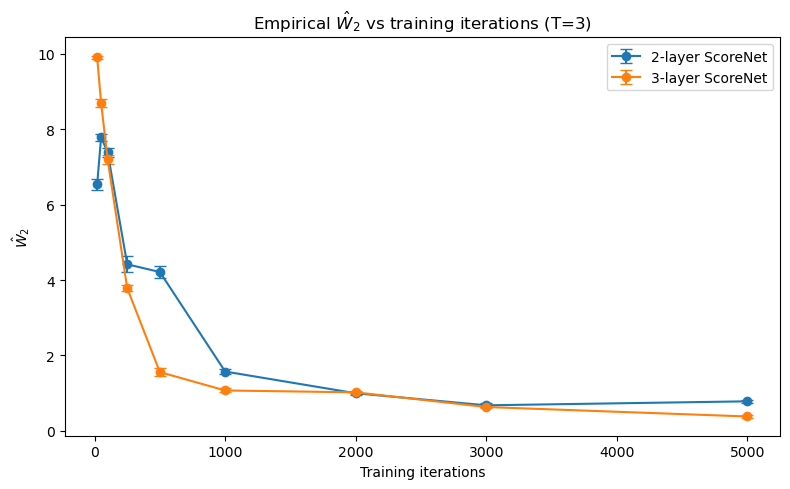

In [14]:
results_T3 = fct.load_results("outputs/results_T3.pt")
fct.plot_W2_curve(results_T3, title_suffix="(T=3)")

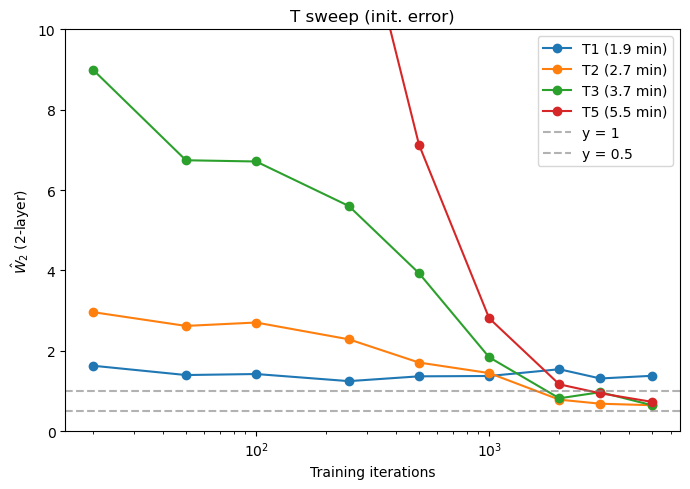

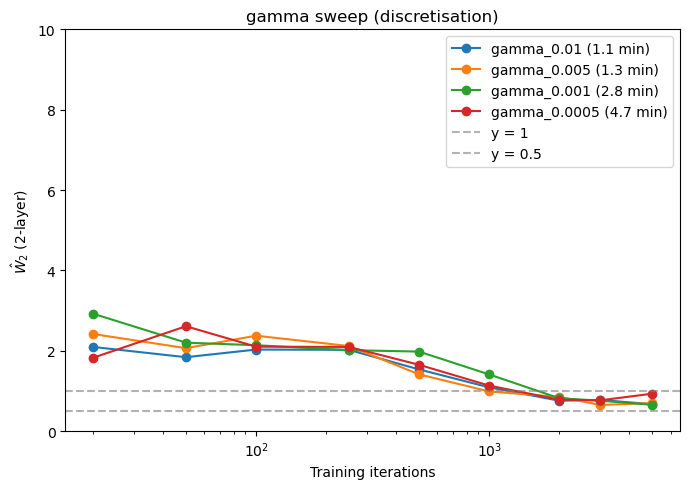

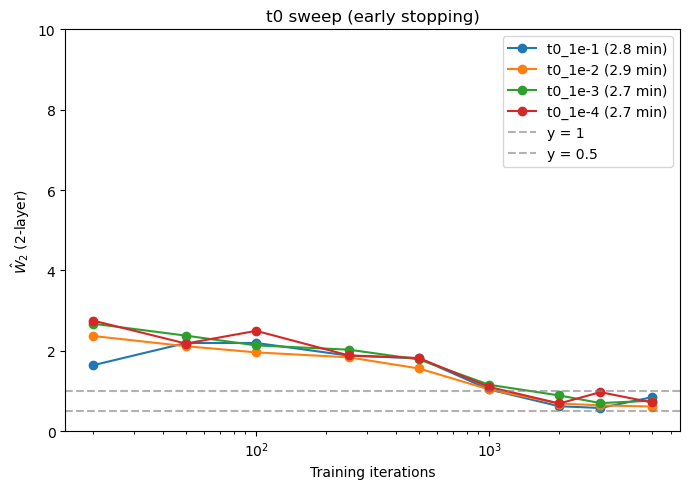

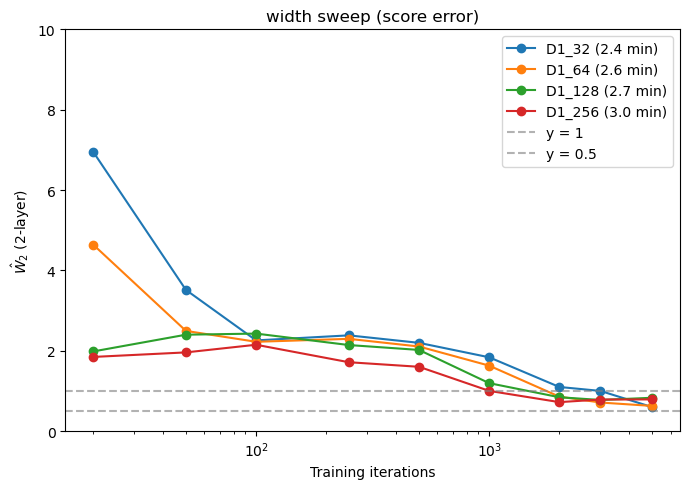

In [17]:
import functions2 as fct
import matplotlib.pyplot as plt

groups = {
    "T sweep (init. error)": ["T1", "T2", "T3", "T5"],
    "gamma sweep (discretisation)": ["gamma_0.01", "gamma_0.005", "gamma_0.001", "gamma_0.0005"],
    "t0 sweep (early stopping)": ["t0_1e-1", "t0_1e-2", "t0_1e-3", "t0_1e-4"],
    "width sweep (score error)": ["D1_32", "D1_64", "D1_128", "D1_256"],
}

all_results = {}
for group_name, tags in groups.items():
    all_results[group_name] = {tag: fct.load_results(f"outputs/results_{tag}.pt") for tag in tags}

for group_name, results_by_tag in all_results.items():
    plt.figure(figsize=(7, 5))
    for tag, results in results_by_tag.items():
        runtime = results.get("runtime_seconds")
        label = f"{tag}" + (f" ({runtime/60:.1f} min)" if runtime else "")
        plt.plot(results["checkpoints"], results["W2_2layer_curve"], marker='o', label=label)

    plt.axhline(y=1, linestyle='--', color='gray', alpha=0.6, label='y = 1')
    plt.axhline(y=0.5, linestyle='--', color='gray', alpha=0.6, label='y = 0.5')

    plt.xlabel("Training iterations")
    plt.ylabel(r"$\hat{W}_2$ (2-layer)")
    plt.xscale('log')
    plt.ylim(0, 10)
    plt.title(group_name)
    plt.legend()
    plt.tight_layout()
    plt.show()